*updated 19 Oct 2025, Julian Mak (whatever with copyright, do what you want with this)

### As part of material for OCES 4303 "AI and Machine Learning in Marine Science" delivered at HKUST

For the latest version of the material, go to the public facing [GitHub](https://github.com/julianmak/OCES4303_ML_ocean) page.

---
# 10. Misc. neural network architectures

There are a whole zoo of other possible neural network architectures available. Instead of going through all of them, I'm going to pick a few to describe in a bit more detail. The criteria for choosing the ones below are one that I think are sufficiently easy to describe, small enough to implement, and have applications in things that I am interested in (in this case particularly with ***time evolving*** data).

Because of the technicality criterion I am not going to talk about ***Generative Adversarial Networks*** (GANs) and ***Physics Informed Neural Networks*** (PINNs). Both are mega-interesting to me and involve mathematics, and may be part of (separate) bonus lectures.

> ## Key Objective(s)
> 1. Introduce auto-encoders and demonstrate some possible uses of those.
> 2. Introduce recurrent neural networks and demonstrate its use in time-series predictions.
> 3. Demonstrating some further utility of `pyTorch`.

In [1]:
# load some packages

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

---
## a) Auto-encoders

Auto-encoders can be thought of as *unsupervised* neural networks, although they are trained in the supervising sense. The **auto** refers to output and input being (basically) the same (acting on itself in a sense).

There are then two parts to the auto-encoder architecture:

1. The ***encoder***, which compresses information by squeezing the feature dimension down to some ***latent space***, and is a neural network of some description.
2. The ***decoder***, which blows up the latent space representation back up to the original dimension, and is a also neural network of some description.

Pictorially this is represented as follows:

<img src="https://i.imgur.com/n2dcFVU.png" width="600" alt='autoencoder'>

> NOTE: The decoder does not have to have a structure that exactly mirror the encoder or vice-versa. You just need them to have appropriate dimensions.
>
> You can have them convolutions in there; see extended exercise later with regards to ***convolutional auto-encoders***.

The idea is that the encoder is trained to squash out the unnecessary information, resulting in a lower dimension representation. The decoder on the other hand is trained to recover the original data using that lower dimension representation. The below demonstrates two possible uses of this (although it's not done all that well, because the chosen problem is deliberately hard).

### 1) Latent space representation (cf. alternative to PCA et al.)

In `03_linear_models_dim_reduction` we considered several ways to reduce the dimensionality of data, but we could also do it using neural networks. Going to do the easy case with `penguins` data first.

In [2]:
# load the penguin data
option = "remote"

if option == "local":
    print("loading data locally (assumes file has already been downloaded)")
    path = "penguins.csv"
elif option == "remote":
    print("loading data remotely")
    path = "https://raw.githubusercontent.com/julianmak/OCES4303_ML_ocean/refs/heads/main/penguins.csv"
else:
    raise ValueError("INVALID OPTION: use 'remote' or 'local'")

df = pd.read_csv(path)

features = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
X = df[features].values
X_scaled = StandardScaler().fit_transform(X)

loading data remotely


Here I am going to define a really simple single layer autoencoder, consisting of `layer_in`, which is used in the encoder to map the four dimensional features space to two, and `layer_out`, which is the decoder to map it back to four dimensions, both to have ReLU as the activation function. The forward then consists of encoder followed by the decoder.

I am splitting out the encoder and decoder as separate components in the class because I want to use them separately later.

In [3]:
# define really simple auto-encoder (two parts jammed together: encoder and decoder)

class autoencoder_latent_penguin(nn.Module):
    def __init__(self):
        super(autoencoder_latent_penguin, self).__init__()
        
        # encoder part: shrink it down to get latent space representation
        self.layer_in = nn.Linear(4, 2)
        
        # decoder part: blow it back up for regenerating image
        self.layer_out = nn.Linear(2, 4)

    def encoder(self, x):
        x = F.relu(self.layer_in(x))
        return x

    def decoder(self, x):
        x = F.relu(self.layer_out(x))
        return x

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

For this auto-encoder, the input and output data is the same.

In [4]:
# to tensor
X_train, Y_train = torch.FloatTensor(X_scaled), torch.FloatTensor(X_scaled)

Below defines the training loop subroutine and does the training (it's just a copy-and-paste job from last time, with the validation part removed).

In [5]:
# wrap the training up

def training_no_validation(model, optimizer, J, X_train, Y_train,
                           num_epochs=500, out_epoch=50):

    # define things to dump into for loss curve
    train_J = np.zeros(num_epochs)

    for epoch in range(num_epochs):

        # iteration step

        model.train()  # put the model in training mode (taping is on)
        optimizer.zero_grad()  # clear gradients if it exists (from loss.backward())
        Y_pred = model(X_train)  # feed-forward
        J_train = J(Y_pred, Y_train) # compute loss
        J_train.backward()  # back propagation
        optimizer.step()  # iterate
        model.eval()   # put the model in evaluation mode (taping is off for diags below)

        # diagnostics: evaluation of metrics as we go along
        train_J[epoch] = J_train.item()

        if (epoch + 1) % out_epoch == 0:
            print(f"Epoch {epoch+1}/{num_epochs}, "
                + f"Train Loss: {J_train.item():.4f}")

    return model, train_J

model details: autoencoder_latent_penguin(
  (layer_in): Linear(in_features=4, out_features=2, bias=True)
  (layer_out): Linear(in_features=2, out_features=4, bias=True)
)
 
Epoch 40/400, Train Loss: 0.8656
Epoch 80/400, Train Loss: 0.7777
Epoch 120/400, Train Loss: 0.7630
Epoch 160/400, Train Loss: 0.7612
Epoch 200/400, Train Loss: 0.7606
Epoch 240/400, Train Loss: 0.7603
Epoch 280/400, Train Loss: 0.7601
Epoch 320/400, Train Loss: 0.7599
Epoch 360/400, Train Loss: 0.7596
Epoch 400/400, Train Loss: 0.7586


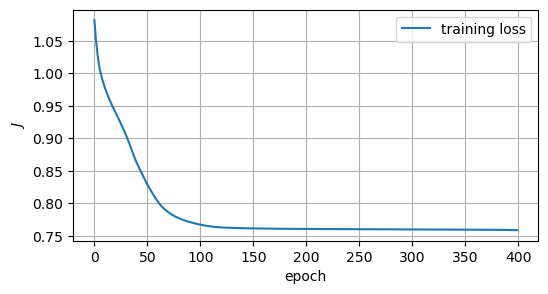

In [6]:
# initialisations and train the model

torch.manual_seed(1234)

model = autoencoder_latent_penguin()
learning_rate = 0.01
J = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)  # default is 0.001

print(f"model details: {model}")
print(" ")

# cheat here
model, train_J = training_no_validation(model, optimizer, J, X_train, Y_train,
                                        num_epochs=400, out_epoch=40)

# plot the loss curves
fig = plt.figure(figsize=(6, 3))
ax = plt.axes()
ax.plot(train_J, label="training loss")
ax.set_xlabel("epoch")
ax.set_ylabel(r"$J$")
ax.grid()
ax.legend();

For this one I am mainly interested in showing the ***latent*** space representation. This I can get by calling the encoder part of the model, and because I chose my encoder to map from four to two dimensions. Below does the call and plots out the results, labelled by the species.

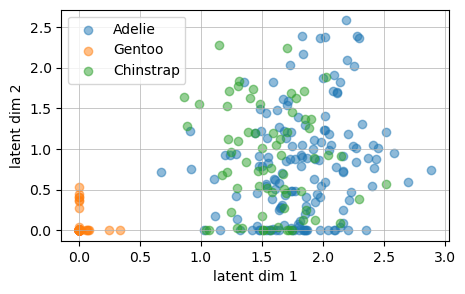

In [7]:
# latent space representation
with torch.no_grad():
    latent_rep_train = model.encoder(X_train).numpy()

fig = plt.figure(figsize=(5, 3))
ax = plt.axes()
for species in df["species"].unique():   # pick out all unique entries under `species`
    ax.scatter(latent_rep_train[df["species"] == species, 0],
               latent_rep_train[df["species"] == species, 1],
               label=species,
               alpha=0.5,  # fade this for demonstration later
               )
ax.set_xlabel(f"latent dim 1")
ax.set_ylabel(f"latent dim 2")
ax.grid(lw=0.5, zorder=0)
ax.legend();

You can think of this as a neural network equivalent of PCA or similar, where the network finds the optimal co-ordinate transformation/project. Given enough depth and breadth it may be that the auto-encoder captures a good latent space representation that may be computationally out of reach with other procedures.

### 2) Generating new data from the decoder

Above only really uses the encoder, but you could imagine that you can choose numbers strategically in the latent space representation (cf. choosing the co-ordinates of the latent space), feed that into the decoder to artificially generate new data; this may be a useful way to generate new data from an existing dataset.

An equivalent larger dimension problem would be you take a set of images, train an auto-encoder, and use the decoder part to generate new images. Going to briefly show how that works with the cats image set.

> NOTE: It doesn't work very well here because the number of images is rather low, and also to make the model train in sensible time I can't make the auto-encoder too deep or wide.
>
> In this case having CNN based encoders and decoders would probably work better anyway...

In [8]:
# don't read the headers

option = "remote"

if option == "local":
    print("loading data locally (assumes file has already been downloaded)")
    path = "cat.csv"
elif option == "remote":
    print("loading data remotely")
    path = "https://raw.githubusercontent.com/julianmak/OCES4303_ML_ocean/refs/heads/main/cat.csv"
else:
    raise ValueError("INVALID OPTION: use 'remote' or 'local'")

df_cats = pd.read_csv(path, header=None).T # make "features" the axis=-1
X_cats = df_cats.values

if option == "local":
    print("loading data locally (assumes file has already been downloaded)")
    path = "dog.csv"
elif option == "remote":
    print("loading data remotely")
    path = "https://raw.githubusercontent.com/julianmak/OCES4303_ML_ocean/refs/heads/main/dog.csv"
else:
    raise ValueError("INVALID OPTION: use 'remote' or 'local'")

df_dogs = pd.read_csv(path, header=None).T # make "features" the axis=-1
X_dogs = df_dogs.values

loading data remotely
loading data remotely


In [9]:
# load data
seed = 42
train_ratio = 0.7
valid_ratio = 0.15
test_ratio = 0.15
test_valid_ratio = valid_ratio + test_ratio
assert train_ratio + valid_ratio + test_ratio == 1

# Expected no. of samples
print()
total_sample = 80*2
train_sample = int(train_ratio*total_sample)
valid_sample = int(valid_ratio*total_sample)
test_sample = total_sample - train_sample - valid_sample
print(f"Expected no. of samples (train, test, valid): {train_sample, test_sample, valid_sample}")

X_total = X_cats  # TODO: cat/dog mix to generate more cursed examples?
Y_total = X_cats

# train-(test&valid) split
X_train, X_test, Y_train, Y_test = train_test_split(
    X_total, Y_total, test_size=test_valid_ratio, random_state=seed,)
# split test set to test and valid set
X_test, X_valid, Y_test, Y_valid = train_test_split(
    X_test, Y_test, test_size=valid_ratio/test_valid_ratio, random_state=seed,)

# check the shape
print()
print(f"X_train shape : {X_train.shape}; Y_train shape: {Y_train.shape}")
print(f"X_valid shape: {X_valid.shape}; Y_valid shape: {Y_valid.shape}")
print(f"X_test shape: {X_test.shape}; Y_test shape: {Y_test.shape}")

# # scale and redefine the data
scaler = StandardScaler()
scaler.fit(X_train)
X_train, X_valid, X_test = \
  scaler.transform(X_train), scaler.transform(X_valid), scaler.transform(X_test)

# check the range of values
print()
print(f"X_train : {X_train.min()}...{X_train.max()}")
print(f"X_valid : {X_valid.min()}...{X_valid.max()}")
print(f"X_test :  {X_test.min()}...{X_test.max()}")


Expected no. of samples (train, test, valid): (112, 24, 24)

X_train shape : (56, 4096); Y_train shape: (56, 4096)
X_valid shape: (12, 4096); Y_valid shape: (12, 4096)
X_test shape: (12, 4096); Y_test shape: (12, 4096)

X_train : -3.1076754953949437...2.853157223387415
X_valid : -3.272451616574566...2.868553178199615
X_test :  -3.2001166984904366...2.8348170843897096


In the autoencoder below I make it go from $64^2$ to $16^2$ then $4^2$ with the usual fully connected neural networks, then I reverse that process. The jumps in the dimensions are reasonably big, so we don't really expect this to work all that well.

I go ahead with preping the data and throw it in the training loop.

In [10]:
# define the auto-encoder (two parts jammed together: encoder and decoder)

class autoencoder_latent(nn.Module):
    def __init__(self):
        super(autoencoder_latent, self).__init__()

        # splitting the parts out because I want encoder and decoder 
        # as separate things I can call
        
        # encoder part: shrink it down to get latent space representation
        self.layer_in_1 = nn.Linear(64**2, 16**2)
        self.layer_in_2 = nn.Linear(16**2, 4**2)
        
        # decoder part: blow it back up for regenerating image
        self.layer_out_1 = nn.Linear(4**2, 16**2)   
        self.layer_out_2 = nn.Linear(16**2, 64**2)

    def encoder(self, x):
        x = F.relu(self.layer_in_1(x))
        x = F.relu(self.layer_in_2(x))
        return x

    def decoder(self, x):
        x = F.relu(self.layer_out_1(x))
        x = F.relu(self.layer_out_2(x))
        return x

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        # may or may not want an activation here 
        # (sigmoid activation doesn't really work for me here; probably not deep enough)
        return x

In [11]:
# wrap the training up

def training(model, optimizer, J, X_train, Y_train, X_valid, Y_valid,
             num_epochs=500, out_epoch=50):

    # define things to dump into for loss curve
    train_J = np.zeros(num_epochs)
    valid_J = np.zeros(num_epochs)

    for epoch in range(num_epochs):

        # iteration step

        model.train()  # put the model in training mode (taping is on)
        optimizer.zero_grad()  # clear gradients if it exists (from loss.backward())
        Y_pred = model(X_train)  # feed-forward
        J_train = J(Y_pred, Y_train) # compute loss
        J_train.backward()  # back propagation
        optimizer.step()  # iterate
        model.eval()   # put the model in evaluation mode (taping is off for diags below)

        # diagnostics: evaluation of metrics as we go along
        with torch.no_grad():  # force no taping just in case
            Y_pred = model(X_valid)
            J_valid = J(Y_pred, Y_valid)
            train_J[epoch] = J_train.item()
            valid_J[epoch] = J_valid.item()

        if (epoch + 1) % out_epoch == 0:
            print(f"Epoch {epoch+1}/{num_epochs}, "
                + f"Train Loss: {J_train.item():.4f}, "
                + f"Validation Loss: {J_valid.item():.4f}")

    return model, train_J, valid_J

In [12]:
# to tensor
X_train, Y_train = torch.FloatTensor(X_train), torch.FloatTensor(Y_train)
X_test, Y_test = torch.FloatTensor(X_test), torch.FloatTensor(Y_test)
X_valid, Y_valid = torch.FloatTensor(X_valid), torch.FloatTensor(Y_valid)

model details: autoencoder_latent(
  (layer_in_1): Linear(in_features=4096, out_features=256, bias=True)
  (layer_in_2): Linear(in_features=256, out_features=16, bias=True)
  (layer_out_1): Linear(in_features=16, out_features=256, bias=True)
  (layer_out_2): Linear(in_features=256, out_features=4096, bias=True)
)
 
Epoch 40/400, Train Loss: 1817.5424, Validation Loss: 3962.2610
Epoch 80/400, Train Loss: 860.5497, Validation Loss: 3732.8457
Epoch 120/400, Train Loss: 400.7232, Validation Loss: 3655.1702
Epoch 160/400, Train Loss: 248.5508, Validation Loss: 3711.1667
Epoch 200/400, Train Loss: 191.9207, Validation Loss: 3766.1204
Epoch 240/400, Train Loss: 170.4534, Validation Loss: 3765.7129
Epoch 280/400, Train Loss: 164.5386, Validation Loss: 3787.4285
Epoch 320/400, Train Loss: 163.6862, Validation Loss: 3775.8203
Epoch 360/400, Train Loss: 173.9906, Validation Loss: 3708.9910
Epoch 400/400, Train Loss: 163.5309, Validation Loss: 3794.6130


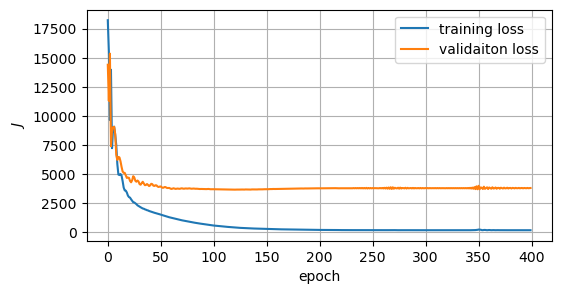

In [13]:
# initialisation and training

torch.manual_seed(1234)

model = autoencoder_latent()
learning_rate = 0.01
J = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)  # default is 0.001

print(f"model details: {model}")
print(" ")

model, train_J, valid_J = training(model, optimizer, J, X_train, Y_train, X_valid, Y_valid,
                                   num_epochs=400, out_epoch=40)

# plot the loss curves
fig = plt.figure(figsize=(6, 3))
ax = plt.axes()
ax.plot(train_J, label="training loss")
ax.plot(valid_J, label="validaiton loss")
ax.set_xlabel("epoch")
ax.set_ylabel(r"$J$")
ax.grid()
ax.legend();

It looks not unreasonable on the training loss, but it's pretty bad on the validation dataset. Again this is not entirely surprising, because I have kept the dataset size and neural network complexity low for speed reasons. The below code runs a model prediction to see what the results look like.

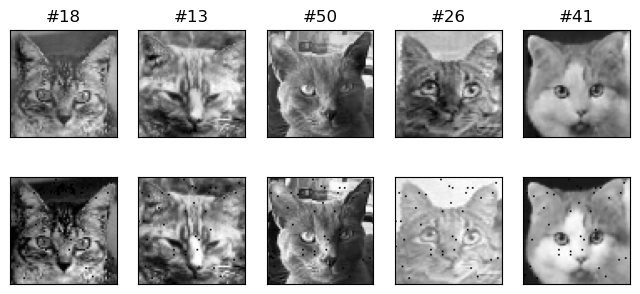

In [14]:
# sample show
with torch.no_grad():
    predictions_train = model(X_train)
    predictions_test = model(X_test)

# generate a list of 25 indices (generate full list, shuffle, select first 25, so no repeats)
ind = np.arange(X_train.shape[0])
np.random.seed(123)
np.random.shuffle(ind)  # syntax for shuffle: not used like a function with input output...

fig = plt.figure(figsize=(8, 3.5))
for i in range(5):
    ax = plt.subplot(2, 5, i+1)
    ax.imshow(np.reshape(X_train[ind[i], :], (64, 64)).T, cmap="gray")
    ax.set_title(f"#{ind[i]}")
    ax.set_xticks([]); ax.set_yticks([]);
    ax = plt.subplot(2, 5, 5+i+1)
    ax.imshow(np.reshape(predictions_train[ind[i], :], (64, 64)).T, cmap="gray")
    ax.set_xticks([]); ax.set_yticks([]);

The bulk of the features are there but there are these random black dots that turns out to be a big contributor to the loss. Probably could get rid of those with a more complex neural network, but this is only for demonstration, so we press on.

We can now do a "PCA" like thing by calling only the encoder to give us the latent space representation.

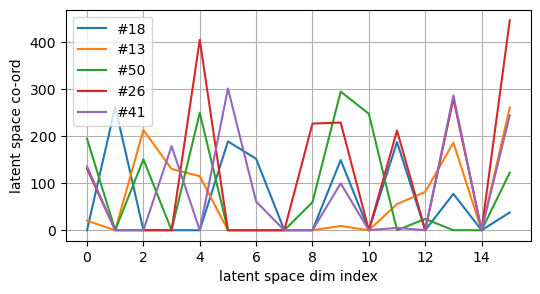

In [15]:
# latent space representation
with torch.no_grad():
    latent_rep_train = model.encoder(X_train).numpy()

# plot out
fig = plt.figure(figsize=(6, 3))
ax = plt.axes()
for i in range(5):
    ax.plot(latent_rep_train[ind[i], :], label=f"#{ind[i]}")
ax.set_xlabel(r"latent space dim index")
ax.set_ylabel(r"latent space co-ord")
ax.legend()
ax.grid()

Each image thus has a "barcode" of sorts tagged with it, given by the numbers associated with each latent space dimension (cf. the PCs under the EOF transformation). You might expect images that are more "alike" (in whatever sense the neural networks decided for it to mean) would be closer to each other.

> NOTE: We may come back to this point relating to barcodes if we talk about ***topological data analysis***.

Now you could choose a selection of numbers (16 in this case), pass it to the *decoder*, and it will spit out an image for you. This we will try now, by:

1. Throwing in a "mean" barcode by taking the mean value of the above.
2. Throwing in a "random" barcode, by randomly selecting existing values from the training dataset as we cycle through the latent space dimension.

> NOTE: The "random" one is constrained to be sampled from the training dataset, because making it truly random is probably going to do something weird; you can try this yourselves.

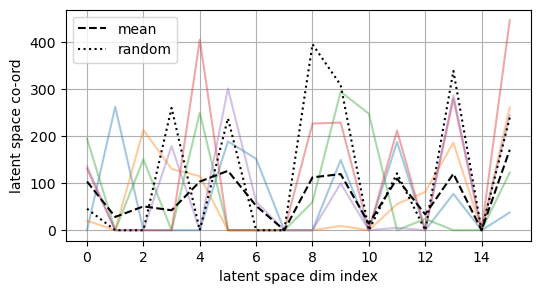

In [16]:
# generate two additional barcodes and plot that out

# take an "average" along the components
mean_representation = np.mean(latent_rep_train, axis=0)

# randomly select some values for the representation from existing pool
n_samples, n_dim = latent_rep_train.shape
rand_representation = np.zeros(n_dim)
for i in range(len(rand_representation)):
    rand_representation[i] = latent_rep_train[np.random.randint(n_samples), i]

# plot out
# plot out
fig = plt.figure(figsize=(6, 3))
ax = plt.axes()
for i in range(5):
    ax.plot(latent_rep_train[ind[i], :], alpha=0.4)
ax.plot(mean_representation, 'k--', label="mean")
ax.plot(rand_representation, 'k:', label="random")
ax.set_xlabel(r"latent space dim index")
ax.set_ylabel(r"latent space co-ord")
ax.legend()
ax.grid()

Text(0.5, 1.0, "'random' cat")

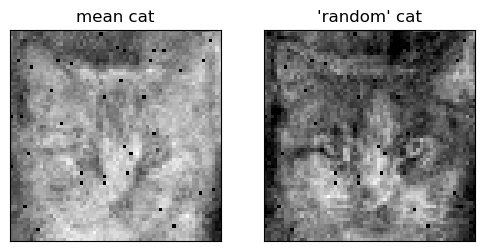

In [17]:
# cursed beast from decoder
with torch.no_grad():
    gen_mean = model.decoder(torch.FloatTensor(mean_representation.reshape(-1, 16)))
    gen_rand = model.decoder(torch.FloatTensor(rand_representation.reshape(-1, 16)))
fig = plt.figure(figsize=(6, 3))
ax = plt.subplot(1, 2, 1)
ax.imshow(np.reshape(gen_mean, (64, 64)).T, cmap="gray")
ax.set_xticks([]); ax.set_yticks([]);
ax.set_title(r"mean cat")

ax = plt.subplot(1, 2, 2)
ax.imshow(np.reshape(gen_rand, (64, 64)).T, cmap="gray")
ax.set_xticks([]); ax.set_yticks([]);
ax.set_title(r"'random' cat")

The "mean" cat is a bit cursed looking and that may not be surprising, because from the barcodes above you notice that the barcodes have a few zero entries, but the mean is definitely not respecting that property.

The "random" cat is perhaps slightly more believable, since that is sampling from existing data.

> <span style="color:red">Q.</span> Try randomly generating a barcode to pass to the encoder to generate more cursed images.
>
> <span style="color:red">Q.</span> Try doing similar things but now including cats and dogs. Investigate if the latent space representation of the two classes look distinctly different, which would indicate it may have skill in doing classification problems (e.g. `05_classification`, or doing classification with neural networks).
>
> Also see what kind of cursed cat-dog things you can generate.

### 3) De-noising data

One application we could use with an autoencoder is ***de-noising*** the data. The idea here is that the output is clean data, while the input is the same data but with noise in, so the autoencoder is trained to remove the noise via some compression and decompression. For this we can more or less do a copy-and-paste job from above, where the only difference is what we put in as input and output data. The below set of code basically does this.

In [18]:
# load data as usual
seed = 42
train_ratio = 0.7
valid_ratio = 0.15
test_ratio = 0.15
test_valid_ratio = valid_ratio + test_ratio
assert train_ratio + valid_ratio + test_ratio == 1

# Expected no. of samples
print()
total_sample = 80*2
train_sample = int(train_ratio*total_sample)
valid_sample = int(valid_ratio*total_sample)
test_sample = total_sample - train_sample - valid_sample
print(f"Expected no. of samples (train, test, valid): {train_sample, test_sample, valid_sample}")

X_total = X_cats
Y_total = X_cats

# train-(test&valid) split
X_train, X_test, Y_train, Y_test = train_test_split(
    X_total, Y_total, test_size=test_valid_ratio, random_state=seed,)
# split test set to test and valid set
X_test, X_valid, Y_test, Y_valid = train_test_split(
    X_test, Y_test, test_size=valid_ratio/test_valid_ratio, random_state=seed,)

# check the shape
print()
print(f"X_train shape : {X_train.shape}; Y_train shape: {Y_train.shape}")
print(f"X_valid shape: {X_valid.shape}; Y_valid shape: {Y_valid.shape}")
print(f"X_test shape: {X_test.shape}; Y_test shape: {Y_test.shape}")

# # scale and redefine the data
scaler = StandardScaler()
scaler.fit(X_train)
X_train, X_valid, X_test = \
  scaler.transform(X_train), scaler.transform(X_valid), scaler.transform(X_test)

# check the range of values
print()
print(f"X_train : {X_train.min()}...{X_train.max()}")
print(f"X_valid : {X_valid.min()}...{X_valid.max()}")
print(f"X_test :  {X_test.min()}...{X_test.max()}")


Expected no. of samples (train, test, valid): (112, 24, 24)

X_train shape : (56, 4096); Y_train shape: (56, 4096)
X_valid shape: (12, 4096); Y_valid shape: (12, 4096)
X_test shape: (12, 4096); Y_test shape: (12, 4096)

X_train : -3.1076754953949437...2.853157223387415
X_valid : -3.272451616574566...2.868553178199615
X_test :  -3.2001166984904366...2.8348170843897096


Here I am going to add some Gaussian noise to the data with some specified `noise_level`, and then plot out some of the noisy and clean image that are exposed to the autoencoder.

> NOTE: My expectation here is that the larger the `noise_level` the harder the autoencoder has to work to remove it; play around with this for later to investigate whether that is true.

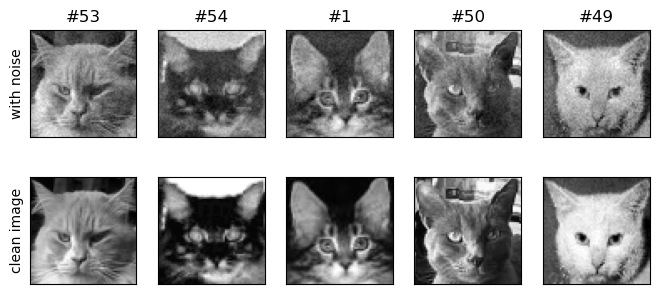

In [19]:
# denoising: add noise to the X_train but keep Y_train clean

noise_level = 0.5  # uniform noise with some magnitude (data here is STANDARDISED)

X_train += noise_level * np.random.rand(X_train.shape[0], 
                                        X_train.shape[1])
X_valid += noise_level * np.random.rand(X_valid.shape[0], 
                                        X_valid.shape[1])
X_test  += noise_level * np.random.rand(X_test.shape[0], 
                                        X_test.shape[1])

# generate a list of indices (generate full list, shuffle, select first whatever, so no repeats)
ind = np.arange(X_train.shape[0])
np.random.shuffle(ind)

fig = plt.figure(figsize=(8, 3.5))
for i in range(5):
    ax = plt.subplot(2, 5, i+1)
    ax.imshow(np.reshape(X_train[ind[i], :], (64, 64)).T, cmap="gray")
    ax.set_title(f"#{ind[i]}")
    if i == 0:
        ax.set_ylabel(r"with noise")
    ax.set_xticks([]); ax.set_yticks([]);
    ax = plt.subplot(2, 5, 5+i+1)
    ax.imshow(np.reshape(Y_train[ind[i], :], (64, 64)).T, cmap="gray")
    ax.set_xticks([]); ax.set_yticks([]);
    if i == 0:
        ax.set_ylabel(r"clean image")

I am going to be lazy and use the same autoencoder defined above; the only thing I need to do is to reinitialise it. The block below is literally copy-and-pasted from above, the only difference being I redefined the *input* data (which has noise included).

model details: autoencoder_latent(
  (layer_in_1): Linear(in_features=4096, out_features=256, bias=True)
  (layer_in_2): Linear(in_features=256, out_features=16, bias=True)
  (layer_out_1): Linear(in_features=16, out_features=256, bias=True)
  (layer_out_2): Linear(in_features=256, out_features=4096, bias=True)
)
 
Epoch 40/400, Train Loss: 1518.4489, Validation Loss: 3569.7625
Epoch 80/400, Train Loss: 545.4595, Validation Loss: 3389.4788
Epoch 120/400, Train Loss: 227.6293, Validation Loss: 3471.3516
Epoch 160/400, Train Loss: 107.0951, Validation Loss: 3503.7803
Epoch 200/400, Train Loss: 85.9975, Validation Loss: 3504.0383
Epoch 240/400, Train Loss: 82.4344, Validation Loss: 3500.5276
Epoch 280/400, Train Loss: 82.3398, Validation Loss: 3432.5442
Epoch 320/400, Train Loss: 96.9822, Validation Loss: 3492.9553
Epoch 360/400, Train Loss: 80.7394, Validation Loss: 3431.8447
Epoch 400/400, Train Loss: 79.7534, Validation Loss: 3432.4026


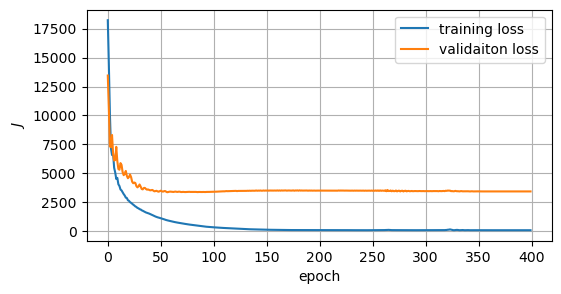

In [20]:
# initialisation and training

X_train, Y_train = torch.FloatTensor(X_train), torch.FloatTensor(Y_train)
X_test, Y_test = torch.FloatTensor(X_test), torch.FloatTensor(Y_test)
X_valid, Y_valid = torch.FloatTensor(X_valid), torch.FloatTensor(Y_valid)

torch.manual_seed(1234)

model = autoencoder_latent()
learning_rate = 0.01
J = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)  # default is 0.001

print(f"model details: {model}")
print(" ")

model, train_J, valid_J = training(model, optimizer, J, X_train, Y_train, X_valid, Y_valid,
                                   num_epochs=400, out_epoch=40)

# plot the loss curves
fig = plt.figure(figsize=(6, 3))
ax = plt.axes()
ax.plot(train_J, label="training loss")
ax.plot(valid_J, label="validaiton loss")
ax.set_xlabel("epoch")
ax.set_ylabel(r"$J$")
ax.grid()
ax.legend();

Below evaluates on both the train and test set.

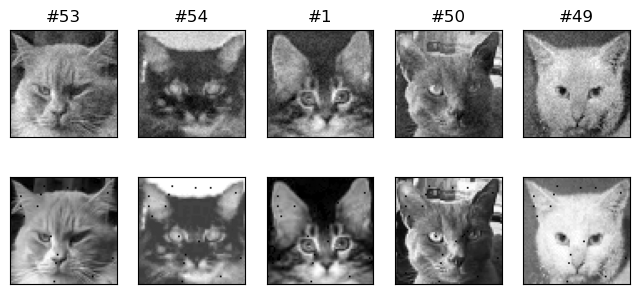

In [21]:
# sample show train set using the same indices as before
with torch.no_grad():
    predictions_train = model(X_train)

fig = plt.figure(figsize=(8, 3.5))
for i in range(5):
    ax = plt.subplot(2, 5, i+1)
    ax.imshow(np.reshape(X_train[ind[i], :], (64, 64)).T, cmap="gray")
    ax.set_title(f"#{ind[i]}")
    ax.set_xticks([]); ax.set_yticks([]);
    ax = plt.subplot(2, 5, 5+i+1)
    ax.imshow(np.reshape(predictions_train[ind[i], :], (64, 64)).T, cmap="gray")
    ax.set_xticks([]); ax.set_yticks([]);

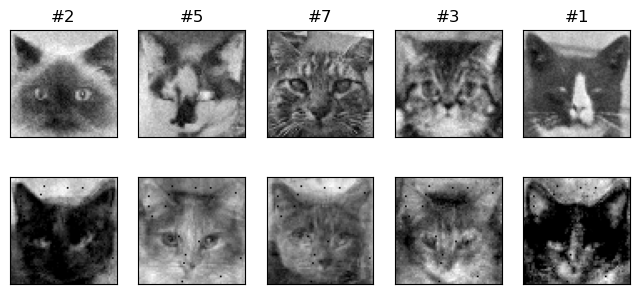

In [22]:
# sample show test set using new indices

with torch.no_grad():
    predictions_test = model(X_test)

# generate a list of indices (generate full list, shuffle, select first whatever, so no repeats)
ind = np.arange(X_test.shape[0])
np.random.shuffle(ind)  # syntax for shuffle: not used like a function with input output...

# sample show (on-the-fly reshape data)
fig = plt.figure(figsize=(8, 3.5))
for i in range(5):
    ax = plt.subplot(2, 5, i+1)
    ax.imshow(np.reshape(X_test[ind[i], :], (64, 64)).T, cmap="gray")
    ax.set_title(f"#{ind[i]}")
    ax.set_xticks([]); ax.set_yticks([]);
    ax = plt.subplot(2, 5, 5+i+1)
    ax.imshow(np.reshape(predictions_test[ind[i], :], (64, 64)).T, cmap="gray")
    ax.set_xticks([]); ax.set_yticks([]);

It is at least believable for the train set, but it's not great on the test set in that it seems to be generating different cats! This is consistent with the loss curves above, and perhaps expected because the sample size is low so it doesn't know how to generalise.

As a just-for-fun test, I am going to hit the three ad-hoc TAs with the trained auto-encoder to see what cursedness results.

In [23]:
import requests
from PIL import Image
from io import BytesIO

# load data remotely
targets_path = {
    "miffy_gormless" : "https://raw.githubusercontent.com/julianmak/OCES4303_ML_ocean/refs/heads/main/miffy_gormless.jpg",
    "blauhaj" : "https://raw.githubusercontent.com/julianmak/OCES4303_ML_ocean/refs/heads/main/blauhaj.jpg",
    "clippy" : "https://raw.githubusercontent.com/julianmak/OCES4303_ML_ocean/refs/heads/main/clippy.jpg",
}

targets = {}

for file_name, file_url in targets_path.items():
    response = requests.get(file_url)
    targets[file_name] = Image.open(BytesIO(response.content))

# massage the data into the right shape, standardise it, and pass it to the model
data = np.concatenate( (np.array(targets["miffy_gormless"]).T.reshape(-1, 64**2),
                        np.array(targets["blauhaj"]).T.reshape(-1, 64**2),
                        np.array(targets["clippy"]).T.reshape(-1, 64**2),
                       )
                     )
data = scaler.transform(data)
data += noise_level * np.random.rand(data.shape[0], 
                                     data.shape[1])
data = torch.FloatTensor(data)
with torch.no_grad():
    predictions_oos = model(data)

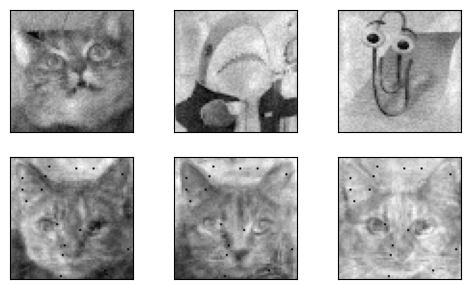

In [24]:
# out-of-sample cursedness
fig = plt.figure(figsize=(6, 3.5))
for i in range(3):
    ax = plt.subplot(2, 3, i+1)
    ax.imshow(np.reshape(data[i, :], (64, 64)).T, cmap="gray")
    ax.set_xticks([]); ax.set_yticks([]);
    ax = plt.subplot(2, 3, 3+i+1)
    ax.imshow(np.reshape(predictions_oos[i, :], (64, 64)).T, cmap="gray")
    ax.set_xticks([]); ax.set_yticks([]);

> <span style="color:red">Q.</span> Experiment with changing the network architecture, train-test-validate ratios and the `noise_level` to see what impact this has on the model skill etc.

---
## b) Recurrent Neural Networks (RNNs) 

The next part is a bit different, more to do ***sequences*** of data. Examples of these are:

* Predictive text
* Time-series data
* Acoustic data (e.g. music)
* Speech data

A difference here is that you think the future states depends on the past, and what you want to do is make predictions based on previous data, i.e. there is some ***memory*** effect. One class of neural networks that builds in some memory effect is the Recurrent Neural Network (RNN). One example of the architecture is below; this is not the only one, but illustrates the some key components of RNNs.

<img src="https://i.imgur.com/fozD28d.png" width="600" alt='rnn'>

> NOTE: You might see it depicted differently in the other online materials, usually described as a feedforward network that gets used repeatedly. The above one makes more sense to me personally because the hidden state makes it a bit more subtle than that "feedforward" description.

The main thing that is different to neural nets introduced so far is the presence of a ***hidden state*** alongside the input data; I am going to refer to the tuple `(input_data, hidden_state)` as the ***input***. Here is that the predictions depends on the hidden state itself, and how `input_data` gets updated depends on the `hidden_state`. For example,  if `f(input_data) = (input_data + hidden_state, input_data)`, then `f(1) = 1` the first time but `f(1) = 2` the second time if `hidden_state = 0` to begin with, since the `hidden_state` has updated when `f` is called the second time.

The ordering of operation above diagram is as follows:

1. Choose input `(input_data, hidden_state)`; `input_data` is from your training data, `hidden_state` is normally initialised to zeroes.
2. `input_data` gets transformed in some way by a neural network block `A` (say).
3. `hidden_state` gets transformed in some way by a different neural network block `B` (say).
4. The returned array of numbers from `A` and `B` are summed and then activated (usually a `tanh` function, although `ReLU` is also used) and returns a `new_hidden_state` (which is an array of numbers).
5. This `new_hidden_state` is transformed by another neural network block `C` and activated accordingly to give an `new_input`.
6. Take the output (`new_input`, `new_hidden_state`) and pass through the RNN again.
7. That generates a sequence of data, from which you can evaluate the loss again the provided training data.
8. Do back-propagation relative to that loss, update the parameters in `A`, `B` and `C`, and iterate.

In this case there is some freedom in how you specify the size of the `hidden_state`, the neural network blocks (`A`, `B`, `C` can in principle all be different as long as their transformation rules are defined consistently), more things can be put in also (e.g. memory gates relating to ***LSTM*** and ***GRU*** architectures), and the neural networks can include convolutions also (e.g. ***ConvLSTM***). For this particular course we are only going to deal with the simple RNNs.

### 1) Time-series data from Lotka-Volterra (or Predator-Prey) model

For the demonstration here we are going to generate some time-series data first. For this I am going to numerically solve the [Lotka-Volterra](https://en.wikipedia.org/wiki/Lotka%E2%80%93Volterra_equations) or ***predator-prey*** model, given by
\begin{equation*}
    \frac{\mathrm{d}x}{\mathrm{d}t} = a x - b x y, \qquad \frac{\mathrm{d}x}{\mathrm{d}t} = -c y - d x y,
\end{equation*}
where ($x$, $y$) = (prey, predators) populations (in some units), and $(a,b,c,d)$ are parameters governing birth, death from predation, death and birth from predation (in some consistent units with how $x$, $y$ and $t$ are defined). I am going to leverage the `scipy` inbuilt functionalities to generate a sequence of data resulting from the model.

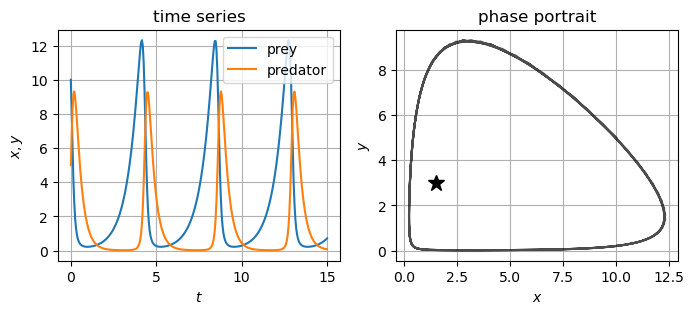

In [25]:
# generate some data from Lotka-Volterra

from scipy.integrate import solve_ivp

def LotkaVolterra(t, z, a, b, c, d):
    x, y = z
    return [a*x - b*x*y, -c*y + d*x*y]

t = np.linspace(0, 15, 300)
a, b, c, d = 1.5, 1, 3, 1
sol = solve_ivp(LotkaVolterra, [0, 15], [10, 5], args=(a, b, c, d), t_eval=t,
               rtol=1e-6, atol=1e-9)
x, y = sol.y

fig = plt.figure(figsize=(8, 3))
ax = plt.subplot(1, 2, 1)
ax.plot(t, x, label=r"prey")
ax.plot(t, y, label="predator")
ax.set_xlabel(r"$t$")
ax.set_ylabel(r"$x, y$")
ax.set_title(r"time series")
ax.legend()
ax.grid()

ax = plt.subplot(1, 2, 2)
ax.plot(x, y, 'k-', alpha=0.7)
ax.plot(a/b, c/d, 'k*', markersize=12)
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$y$")
ax.set_title(r"phase portrait")
ax.grid()

Lotka-Volterra is known to have some cyclic/periodic behaviour, as seen by the time-series but more clearly from the ***phase portrait*** where I plot $x(t)$ against $y(t)$ for all values of $t$. I've also marked on the non-trivial ***equilibrium point*** of this system as a star.

First I want to process the data (which is nested in `sol.y`) to be fed into a RNN. I am going to be lazy and not have any testing data (but see the tests I will do later). In the simplest case I would do a one-step prediction, i.e. the training input data is `[x[i], y[i]]` of `i=0, 1, ... N-1`, and the training output data is `[x[i+1], y[i+1]]` for the same `i` values. In this case the RNN is only ever triggered once; you could argue the it's not really an RNN, but note that there is the hidden state block floating around affecting the outcomes, so it is certainly not the usual neural network either.

The below subroutine is defined to chop up the sequences accordingly, and it's done so that it could in principle produce arbitrary input sequence lengths, which I will use later.

> NOTE: I could introduce randomness by shuffling which samples of sequences I select. I could introduce test and validation data by not passing all the data to the network during the training.

In [26]:
# chop it up into sequences (assumes data sequence is of dim larger than 1)
def create_sequences(data, seq_length=1):
    x_dum, y_dum = [], []
    n_sample = data.shape[0] - seq_length
    for i in range(n_sample):
        x_dum.append(data[i:i+seq_length, :])  # sequence used to predict end point
        y_dum.append(data[i+seq_length, :])    # end point
    return np.asarray(x_dum), np.asarray(y_dum)

X, Y = create_sequences(sol.y.T, seq_length=1)  # need transpose of "sol.y" to get right shape

print(f"input shape is (batch_size, seq, dim) = {X.shape}")
print(f"input shape is (batch_size, dim) = {Y.shape}")

input shape is (batch_size, seq, dim) = (299, 1, 2)
input shape is (batch_size, dim) = (299, 2)


Notice in this case the shape of the inputs has an extra dimension that encodes the input sequence length (in this case it's one).

> NOTE: The resulting singleton dimensions may need to be ***squeezed*** out later.

For the RNN architecture, I could try and build it manually as before, but I could also just use the inbuild `PyTorch` functionality also. In this case I am going to do the latter, because the building from scratch has some minor subtleties that I don't quite understand that impacts the training speed.

> NOTE: `nn.RNN` below defines what is called an [Elman network](https://en.wikipedia.org/wiki/Recurrent_neural_network#Elman_network), which has reasonably simple neural networks blocks. If you want more bespoke networks then you may have to create these yourselves from scratch (which you can, it's just more tedious to do).

The basic RNN here is constructed to take some parameters that will define the RNN architecture for you:

* `input_size`: Dimensionality of input. For the Lotka-Volterra this would be `2` (because ($x,y$))
* `output_size`: Dimensionality of output. For the Lotka-Volterra this would also be `2`, because it' predicting the next state in time.
* `hidden_size`: How big you want the memory block to be. Arguably bigger is better, but this increases your neural network blocks `B` and `C` in the schematic above, which may promote over-fitting and slow down your training steps etc.
* `num_layers`: How many of these Elman RNNs you want to stack together. If you have `num_layers=2`, then you would have neural network blocks `(A1, B1, C1)` and `(A2, B2, C2)` each with their own associated weights and/or biases that are can be trained.

I am going to be keeping it simple and make things reasonably small.

In [27]:
# use torch RNN
class BasicRNN(nn.Module):
    def __init__(self, input_size=1, output_size=1, hidden_size=60, num_layers=1):
        super(BasicRNN, self).__init__()
        self.rnn = nn.RNN(input_size, 
                          hidden_size, 
                          num_layers, 
                          batch_first=True)  # have dimension of batch at position 0
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x): 
        out, _ = self.rnn(x)         # RNN output for ALL time steps (don't need hidden state)
                                     # (hidden state defaults to zero is not initialised)
        out = out[:, -1, :]          # output from the last time step 
        
        return self.fc(out)          # Pass through linear layer

In the definition of the RNN I have suppressed outputting the `hidden_state`, because I don't really need it. I also define a slightly modified training loop (it's the extra `squeeze` command I need for evaluating the loss function). I am also not bothering with the validation here, and  go ahead with the training.

> NOTE: Not going to standarise the data here. You may want to at least min/max the data to `[-1, 1]` or similar. In this case I would argue you probably want to normalise it by non-dimensionalising the data with respect to the birth or decay rate `a` or `b`.

In [28]:
# wrap the training up
def training_RNN(model, optimizer, J, X_train, Y_train,
                 num_epochs=500, out_epoch=50):

    # define things to dump into for loss curve
    train_J = np.zeros(num_epochs)

    for epoch in range(num_epochs):

        # iteration step
        model.train()  # put the model in training mode (taping is on)
        optimizer.zero_grad()  # clear gradients if it exists (from loss.backward())
        Y_pred = model(X_train) # forward
        J_train = J(Y_pred.squeeze(), Y_train)
        J_train.backward()  # back propagation
        optimizer.step()  # iterate
        model.eval()   # put the model in evaluation mode (taping is off for diags below)

        # diagnostistic
        train_J[epoch] = J_train.item()

        if (epoch + 1) % out_epoch == 0:
            print(f"Epoch {epoch+1}/{num_epochs}, "
                + f"Train Loss: {J_train.item():.4f}")

    return model, train_J

Epoch 40/400, Train Loss: 0.4577
Epoch 80/400, Train Loss: 0.1548
Epoch 120/400, Train Loss: 0.0609
Epoch 160/400, Train Loss: 0.0257
Epoch 200/400, Train Loss: 0.0130
Epoch 240/400, Train Loss: 0.0075
Epoch 280/400, Train Loss: 0.0046
Epoch 320/400, Train Loss: 0.0031
Epoch 360/400, Train Loss: 0.0022
Epoch 400/400, Train Loss: 0.0017


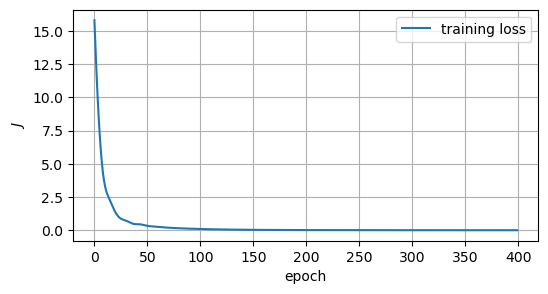

In [29]:
# prep the data and pass it for training

X_train = torch.Tensor(X)  # (batch_size, seq, input)
Y_train = torch.Tensor(Y)

torch.manual_seed(1234)
model = BasicRNN(input_size=2, output_size=2)
learning_rate = 0.01
J = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)  # default is 0.001

model, train_J = training_RNN(model, optimizer, J, X_train, Y_train,
                              num_epochs=400, out_epoch=40)

# loss curve
fig = plt.figure(figsize=(6, 3))
ax = plt.axes()
ax.plot(train_J, label="training loss")
ax.set_xlabel("epoch")
ax.set_ylabel(r"$J$")
ax.grid()
ax.legend();

### "Easy" testing

I am first going to do the easy case first of throwing in the input and seeing what the output is. The given data is going to be markers, and the predictions are lines. According to the loss curve above it should be pretty good.

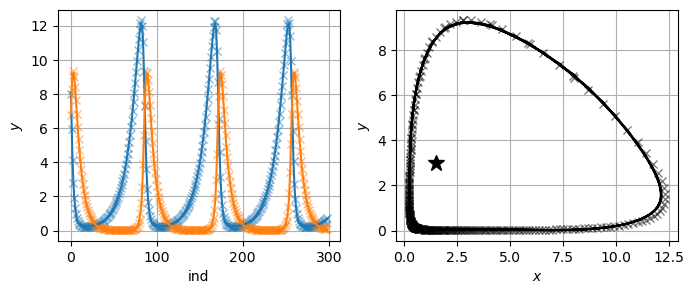

In [30]:
# compare results
with torch.no_grad():
    predictions_train = model(X_train).squeeze().numpy()

fig = plt.figure(figsize=(8, 3))
ax = plt.subplot(1, 2, 1)
ax.plot(Y_train[:, 0], 'C0x', alpha=0.5)
ax.plot(Y_train[:, 1], 'C1x', alpha=0.5)
ax.plot(predictions_train[:, 0], 'C0-')
ax.plot(predictions_train[:, 1], 'C1-')
ax.set_xlabel(r"ind")
ax.set_ylabel(r"$y$")
ax.grid()

ax = plt.subplot(1, 2, 2)
ax.plot(Y_train[:, 0], Y_train[:, 1], 'kx', alpha=0.5)
ax.plot(predictions_train[:, 0], predictions_train[:, 1], "k-")
ax.plot(a/b, c/d, 'k*', markersize=12)
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$y$")
ax.grid()

It looks pretty good, botice in the phase portrait the lines are not directly on top of the markers, near the "top" of the cycle and to the "right" of the cycle.

> NOTE: Could quanitfy this properly with computing the RMS errors over time for example.

### "Harder" testing

Here would be I provide the initial condition, and then keep hitting the predicted output with the RNN. This is a more relevant but harder test because ultimately we might want to use the RNN to make predictions, but the errors with each prediction may accumulate with every pass of the RNN, which may or may not cancel out.

> NOTE: For this nonlinear oscillator we might suspect it would be ok given the limit cycle behaviour, but who knows...

In [31]:
# initialise a who chunk of zeros, dump in the prediction, and use as the next input
predictions_from_init = torch.zeros(Y_train.shape)
X_in = X_train[0, :, :]
with torch.no_grad():
    for i in range(Y_train.shape[0]):
        Y_pred = model(X_in.view(1, 1, 2))
        predictions_from_init[i, :] = Y_pred.squeeze()  # squeeze out singleton dimension
        X_in = Y_pred  # use previous prediction as new input

# do all predictions first before turning it into a numpy array
predictions_from_init = predictions_from_init.numpy()

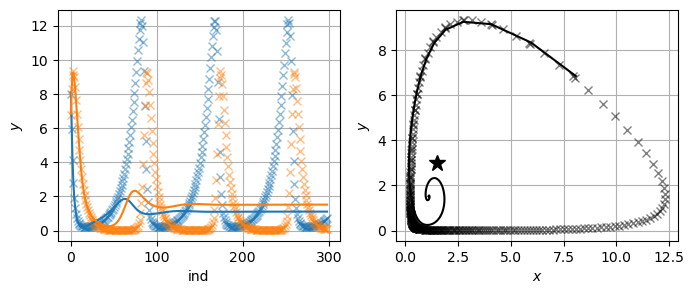

In [32]:
# time series and phase portrait

fig = plt.figure(figsize=(8, 3))
ax = plt.subplot(1, 2, 1)
ax.plot(Y_train[:, 0], 'C0x', alpha=0.5)
ax.plot(Y_train[:, 1], 'C1x', alpha=0.5)
ax.plot(predictions_from_init[:, 0], 'C0-')
ax.plot(predictions_from_init[:, 1], 'C1-')
ax.set_xlabel(r"ind")
ax.set_ylabel(r"$y$")
ax.grid()

ax = plt.subplot(1, 2, 2)
ax.plot(Y_train[:, 0], Y_train[:, 1], 'kx', alpha=0.5)
ax.plot(predictions_from_init[:, 0], predictions_from_init[:, 1], 'k-')
ax.plot(a/b, c/d, 'k*', markersize=12)
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$y$")
ax.grid()

So this one does not do very well after a while, which is perhaps not entirely surprising given we only ask it to do one-step predictions...

### "Hard" test again but increasing the input sequence length

I am going to re-train the model with a longer sequence and then do the "hard" test on it, to see if providing more previous time snapshots will help with the recovering the cyclic behaviour at least.

> NOTE: With increased sequence length I will have a smaller amount of samples. For this case I could always run the model for longer to generate more data, but I am not going to do that for simplicity.

input shape is (batch_size, seq, dim) = (280, 20, 2)
input shape is (batch_size, dim) = (280, 2)
Epoch 40/400, Train Loss: 0.0504
Epoch 80/400, Train Loss: 0.0016
Epoch 120/400, Train Loss: 0.0005
Epoch 160/400, Train Loss: 0.0003
Epoch 200/400, Train Loss: 0.0002
Epoch 240/400, Train Loss: 0.0001
Epoch 280/400, Train Loss: 0.0001
Epoch 320/400, Train Loss: 0.0001
Epoch 360/400, Train Loss: 0.0001
Epoch 400/400, Train Loss: 0.0000


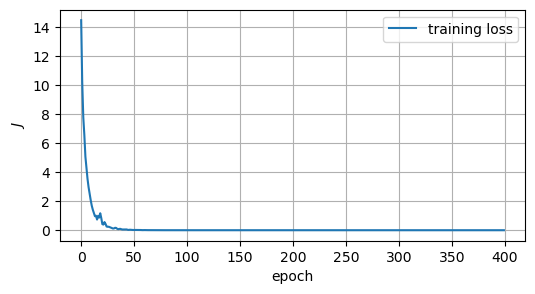

In [33]:
# use longer sequences of data
seq_length = 20
X, Y = create_sequences(sol.y.T, seq_length=seq_length)

print(f"input shape is (batch_size, seq, dim) = {X.shape}")
print(f"input shape is (batch_size, dim) = {Y.shape}")

# prep the data and pass it for training
X_train = torch.Tensor(X)  # (batch_size, seq, input)
Y_train = torch.Tensor(Y)

torch.manual_seed(1234)
model = BasicRNN(input_size=2, output_size=2)
learning_rate = 0.01
J = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)  # default is 0.001

model, train_J = training_RNN(model, optimizer, J, X_train, Y_train,
                              num_epochs=400, out_epoch=40)

# loss curve
fig = plt.figure(figsize=(6, 3))
ax = plt.axes()
ax.plot(train_J, label="training loss")
ax.set_xlabel("epoch")
ax.set_ylabel(r"$J$")
ax.grid()
ax.legend();

In [34]:
# initialise a whole chunk of zeros, dump in the prediction, and use as the next input
predictions_from_init = torch.zeros(Y_train.shape)
X_in = X_train[0, :, :]

with torch.no_grad():
    for i in range(Y_train.shape[0]):
        Y_pred = model(X_in.view(1, seq_length, 2))
        predictions_from_init[i, :] = Y_pred.squeeze()  # squeeze out singleton dimension

        # update the input sequence
        X_dum = torch.zeros(X_in.shape)
        X_dum[0:-1, :] = X_in[1:, :]
        X_dum[-1, :] = Y_pred
        X_in = X_dum

# do all of the calculations first before converting to numpy
predictions_from_init = predictions_from_init.numpy()

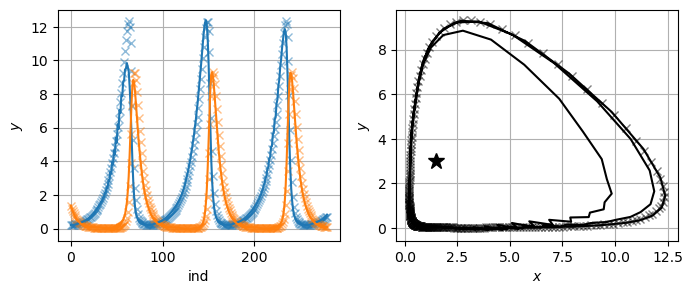

In [35]:
# time series and phase portrait

fig = plt.figure(figsize=(8, 3))
ax = plt.subplot(1, 2, 1)
ax.plot(Y_train[:, 0], 'C0x', alpha=0.5)
ax.plot(Y_train[:, 1], 'C1x', alpha=0.5)
ax.plot(predictions_from_init[:, 0], 'C0-')
ax.plot(predictions_from_init[:, 1], 'C1-')
ax.set_xlabel(r"ind")
ax.set_ylabel(r"$y$")
ax.grid()

ax = plt.subplot(1, 2, 2)
ax.plot(Y_train[:, 0], Y_train[:, 1], 'kx', alpha=0.5)
ax.plot(predictions_from_init[:, 0], predictions_from_init[:, 1], 'k-')
ax.plot(a/b, c/d, 'k*', markersize=12)
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$y$")
ax.grid()

Here we see that if we give it a longer period then the resulting model gets it somewhat wrong at the beginning (the amplitude is too low), but after enough time it seems to recover the cyclic behaviour somewhat. It's certainly better than the previous case...

Going to do a funny one below.

input shape is (batch_size, seq, dim) = (290, 10, 2)
input shape is (batch_size, dim) = (290, 2)
Epoch 40/400, Train Loss: 0.0261
Epoch 80/400, Train Loss: 0.0009
Epoch 120/400, Train Loss: 0.0002
Epoch 160/400, Train Loss: 0.0001
Epoch 200/400, Train Loss: 0.0001
Epoch 240/400, Train Loss: 0.0001
Epoch 280/400, Train Loss: 0.0000
Epoch 320/400, Train Loss: 0.0000
Epoch 360/400, Train Loss: 0.0000
Epoch 400/400, Train Loss: 0.0000


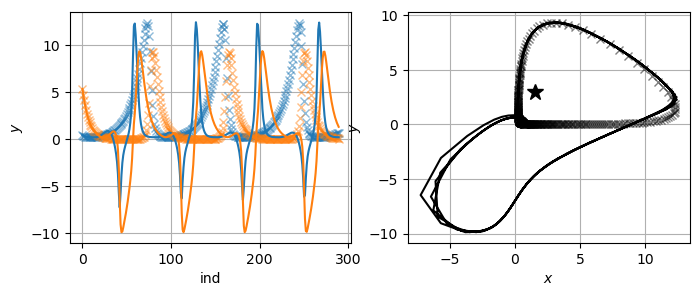

In [36]:
# use longer sequences of data
seq_length = 10
X, Y = create_sequences(sol.y.T, seq_length=seq_length)

print(f"input shape is (batch_size, seq, dim) = {X.shape}")
print(f"input shape is (batch_size, dim) = {Y.shape}")

# prep the data and pass it for training
X_train = torch.Tensor(X)  # (batch_size, seq, input)
Y_train = torch.Tensor(Y)

torch.manual_seed(1234)
model = BasicRNN(input_size=2, output_size=2)
learning_rate = 0.01
J = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)  # default is 0.001

model, train_J = training_RNN(model, optimizer, J, X_train, Y_train,
                              num_epochs=400, out_epoch=40)

# initialise a whole chunk of zeros, dump in the prediction, and use as the next input
predictions_from_init = torch.zeros(Y_train.shape)
X_in = X_train[0, :, :]
with torch.no_grad():
    for i in range(Y_train.shape[0]):
        Y_pred = model(X_in.view(1, seq_length, 2))
        predictions_from_init[i, :] = Y_pred.squeeze()  # squeeze out singleton dimension

        # update the input sequence
        X_dum = torch.zeros(X_in.shape)
        X_dum[0:-1, :] = X_in[1:, :]
        X_dum[-1, :] = Y_pred
        X_in = X_dum

# do all of the calculations first before converting to numpy
predictions_from_init = predictions_from_init.numpy()

# time series and phase portrait

fig = plt.figure(figsize=(8, 3))
ax = plt.subplot(1, 2, 1)
ax.plot(Y_train[:, 0], 'C0x', alpha=0.5)
ax.plot(Y_train[:, 1], 'C1x', alpha=0.5)
ax.plot(predictions_from_init[:, 0], 'C0-')
ax.plot(predictions_from_init[:, 1], 'C1-')
ax.set_xlabel(r"ind")
ax.set_ylabel(r"$y$")
ax.grid()

ax = plt.subplot(1, 2, 2)
ax.plot(Y_train[:, 0], Y_train[:, 1], 'kx', alpha=0.5)
ax.plot(predictions_from_init[:, 0], predictions_from_init[:, 1], 'k-')
ax.plot(a/b, c/d, 'k*', markersize=12)
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$y$")
ax.grid()

From the predator-prey interpretation point of view, here the model predicts "extinction" then "resurrection"! 

Saying that, when the model is not doing insane things, the oscillations are actually alright from the amplitude point of view (from the phase portrait and the time series), although the phase is incorrect. Anyway, the point is there is no guarantee ML models satisfy the underlying model behaviour just from data. How you force the resulting model to satisfy constraints is a different type of beast that we will not deal with here...

> <span style="color:red">Q.</span> Play around with the system parameters ($a,b,c,d$) and/or initial conditions to see how the time-series changes (e.g. whether there are regime shifts), and see how that may or may not affect the RNN performance.
>
> <span style="color:red">Q.</span> Play around with the sequence length you provide to it and see what happens.
> 
> <span style="color:red">Q.</span> Introduce train-test-validate accordingly.
>
> <span style="color:red">Q.</span> Suppose you train an RNN on a time-series trained on a specific choice of ($a,b,c,d$). How does it perform if you deploy the same RNN but on a time-series associated with a different choice ($a,b,c,d$)? Does it depend on the exact regime (cf. above question).
> 
> <span style="color:red">Q.</span> Consider adding noise to the data and then do the training.
>
> <span style="color:red">Q.</span> Consider training a neural network to denoise the data and then do the RNN training. You could do the denoising of the predictions on the fly, or before you pass the data into the training.

----------------
# More involved exercises with this notebook

## 1) Convolutional autoencoders

Have a look at how you might have CNN-based encoders and decoders, which may work better for the problem dealing with images. I'd start with building a decoder that mirrors the encoder to keep it simple. For this case you will want to use `nn.ConvTranspose2d` in the decoder to mirror the `nn.Conv2d` operations in the encoder.

## 2) Using the larger cats image dataset

The above codes demonstrate how an autoencoder works but the performance is not great, largely attributed to the sample size being rather low. Have a look at using the larger set of cats images that I used for eigencat in `03_linear_models_dim_reduction` instead.

Here you almost certainly want to wrap the set of images into a `Dataset` and `DataLoader` object, and pass those to the training model. The main reason being then you can specify `batch_size` to pass to the model training step, which you will most likely need to make the problem complete in sensible time.

## 3) RNN for the Lorenz (1963) model

The code for generating the data for the famous butterfly diagram from the [Lorenz (1963) model](https://en.wikipedia.org/wiki/Lorenz_system) is given below. Have a look at deploying RNNs for that; you will need to modify the sizes here because the Lorenz63 model state is described by three variables. 

This is an example where we have [chaos](https://en.wikipedia.org/wiki/Chaos_theory) in the sense of sensitive dependence on initial conditions, and the predictive step is particularly hard. 

The question might not be whether we have skill in predicting the state $(x,y,z)$, but whether the resulting model at least respects the statistics, i.e. whether the predictions swirl round the two wings. Compare this to predicting the weather and the climate respectively.

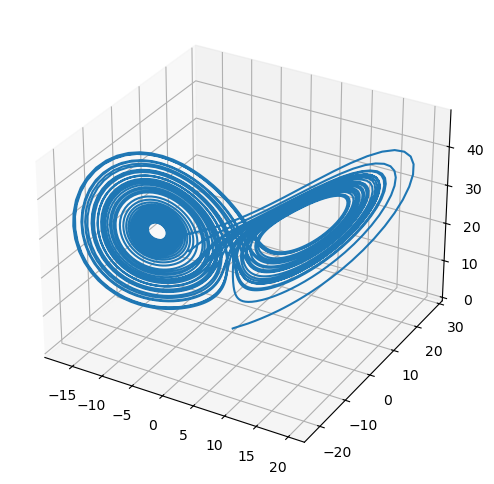

In [37]:
from mpl_toolkits.mplot3d import Axes3D

def lorenz63(t, state, sigma, rho, beta):
    x, y, z = state
    dx = sigma * (y - x)
    dy = x * (rho - z) - y
    dz = x * y - beta * z
    return [dx, dy, dz]

state0 = [1.0, 1.0, 1.0]  # Initial state
params = (10.0, 28.0, 8.0/3.0)  # sigma, rho, beta

t = np.linspace(0, 50, 5000)
sol = solve_ivp(lorenz63, [t[0], t[-1]], [0.1, 0.1, 0.1], t_eval=t, args=params)

x, y, z = sol.y

fig = plt.figure(figsize=(6, 6))
ax = plt.axes(projection="3d")
ax.plot(x, y, z)

## 4) Long Short-Term Memory (LSTM) and Gated Recurrent Unit (GRU)

[LSTM](https://en.wikipedia.org/wiki/Long_short-term_memory) and [GRU](https://en.wikipedia.org/wiki/Gated_recurrent_unit) are popular variations of the RNN architecture, both introducing extra ***gates*** in the neural network architecture to control information flow (e.g. a ***forget*** gate that controls which bits of information are important, to combat vanishing gradient problems sometimes encountered by traditional RNNs). Have a try using `nn.LSTM` and `nn.GRU` instead of `nn.RNN` in the architectures above.

Note that instead of e.g. `out, _ = self.rnn(x)`, which suppresses the output of the hidden state, you may need to do `out, _, _ = self.lstm(x)` since LSTM and GRU returns (output, hidden state, cell state), which you probably don't need those explicitly anyway.

## 5) Convolution + RNNs

Have a look at how you might build an imaged based RNN, which might for example describe how a field might evolve (e.g. SSH evolution over time). A popular one used is called [Convolutional LSTM (ConvLSTM)](https://dl.acm.org/doi/10.5555/2969239.2969329).